## Low rank solutions
This notebook looks at the residuals $r^{(i)} = \| K^T M_\partial y - H X^{(i)} \|_F = \| \nabla \Phi (X^{(i)}) \|_F$ when increasing the rank $r$.


---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from fenics import Function, plot
from utils.problem_setup import TestProblemsSetup
from algorithms.cg_solvers import DynamicalLowRankPCG, frobenius2, ConjugateGradient
from algorithms.rsvd_solvers import MatrixFreeRSVD

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 15,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

SEED = 15
SETUP = TestProblemsSetup(n=64)
PROBLEMS = SETUP.get_test_problems()
PROBLEM_PARAMS = SETUP.problem_params

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
def experiment(r_list, pid, max_iter=500, lambda_=1e-4):
    pb = PROBLEMS[pid]
    rsvd = MatrixFreeRSVD(pb['V_h']); rsvd.solve(k=50, seed=SEED)
    w = rsvd.weights()
    errors, residuals = [], []

    solver = DynamicalLowRankPCG(rsvd, pb['x'])
    for r in r_list:
        x = solver.solve(pb['y'], w,
            lambda_=lambda_, max_iter=max_iter, max_rank=r, rtol=0, etol=0, seed=SEED,
            restart_every=10, preconditioner='none'
        )
        X = solver.vec_to_matrix(x)
        G = solver.gradient(X, pb['y'], w, lambda_**2)  # note: lambda**2 (see solve)

        residuals.append(np.sqrt(frobenius2(G)))
        errors.append(np.linalg.norm(x - pb['x']))

    # Find full rank error and residual
    solver_cg = ConjugateGradient(rsvd, pb['x'])
    x_cg = solver_cg.solve(pb['y'], w,
        lambda_=lambda_, max_iter=max_iter, rtol=0, etol=0, seed=SEED,
    )

    X_cg = solver_cg.vec_to_matrix(x_cg)
    G_cg = solver_cg.gradient(X_cg, pb['y'], w, lambda_**2)  # note: lambda**2 (see solve)
    res_cg = np.sqrt(frobenius2(G_cg))
    err_cg = np.linalg.norm(x_cg - pb['x'])

    return dict(res=residuals, err=errors, res_cg=res_cg, err_cg=err_cg)

In [3]:
r_list = np.arange(1, 11)

resultsI = experiment(r_list, 'I', max_iter=10_000)
resultsII = experiment(r_list, 'II', max_iter=10_000)

[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000


../../figures/low_rank_residual.png already exists


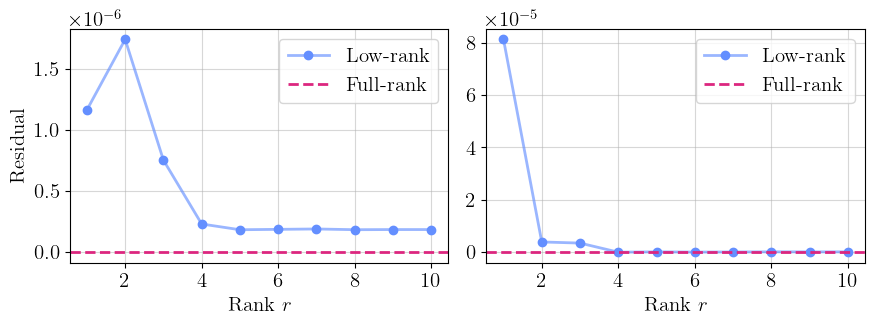

In [41]:
from matplotlib.lines import Line2D
from utils.colors import C2, M, MS
from utils.plotting import save_plot


def plot_results(resultsI, resultsII, fig_name=None):
    M = ['o', None]
    ALPHAS = [0.65, 1.0]
    LS = ['-', '--']

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), sharey=False)
    ax1, ax2 = axes
    
    # Residual plot I
    ax1.plot(r_list, resultsI['res'], c=C2[0], lw=2, alpha=.65)
    #ax1.plot(r_list, resultsI['err'], c=C2[0], lw=2, alpha=.65)
    ax1.plot(r_list, resultsI['res'], M[0], c=C2[0], lw=2)
    ax1.axhline(resultsI['res_cg'], ls='--', c=C2[1], lw=2)

    # Residual plot II
    ax2.plot(r_list, resultsII['res'], c=C2[0], lw=2, alpha=.65)
    ax2.plot(r_list, resultsII['res'], M[0], c=C2[0], lw=2)
    ax2.axhline(resultsII['res_cg'], ls='--', c=C2[1], lw=2)

    ax1.set_ylabel('Residual')
    #ax2.set_ylabel('Error')

    labels = ['Low-rank', 'Full-rank']
    handles = []
    for i in range(2):
        legend_line = Line2D([0], [0], color=C2[i], linewidth=2.0, alpha=ALPHAS[i], linestyle=LS[i])
        legend_marker = Line2D([0], [0], color=C2[i], marker=M[i], markersize=MS[i], linestyle='None')
        handles.append((legend_line, legend_marker))

    for ax in axes:
        ax.set_xlabel('Rank $r$')
        ax.grid(True, alpha=.5)
        ax.legend(handles=handles, labels=labels)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.1)#() hspace=0.1)
    save_plot(fig_name)
    plt.show()


plot_results(resultsI, resultsII, fig_name='low_rank_residual')
#plot_results(resultsII, fig_name='low_rank_residual_II')


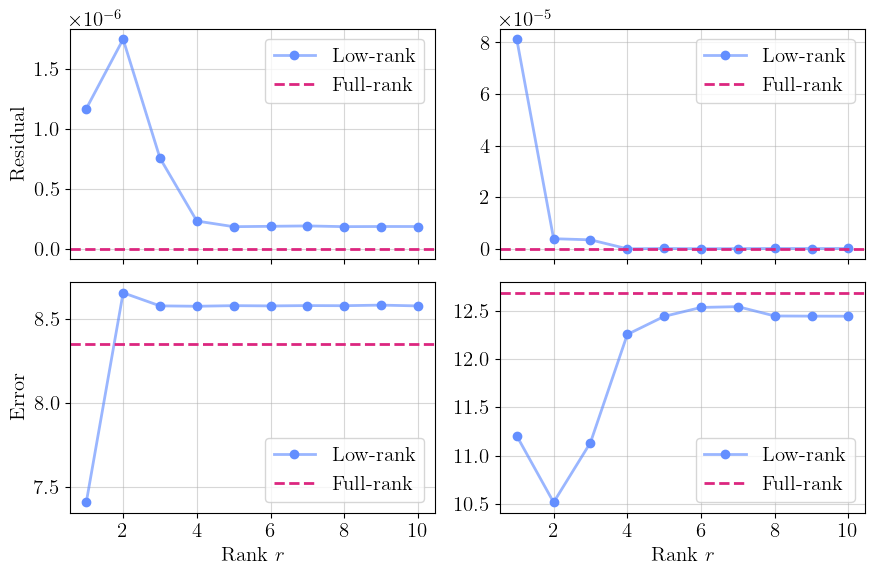

In [56]:
from matplotlib.lines import Line2D
from utils.colors import C2, M, MS
from utils.plotting import save_plot


def plot_results2(resultsI, resultsII, fig_name=None):
    M = ['o', None]
    ALPHAS = [0.65, 1.0]
    LS = ['-', '--']

    fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharex=True)
    ((ax1, ax2), (ax3, ax4)) = axes
    
    # Residual plot I
    ax1.plot(r_list, resultsI['res'], c=C2[0], lw=2, alpha=.65)
    ax1.plot(r_list, resultsI['res'], M[0], c=C2[0], lw=2)
    ax1.axhline(resultsI['res_cg'], ls='--', c=C2[1], lw=2)

    # Residual plot II
    ax2.plot(r_list, resultsII['res'], c=C2[0], lw=2, alpha=.65)
    ax2.plot(r_list, resultsII['res'], M[0], c=C2[0], lw=2)
    ax2.axhline(resultsII['res_cg'], ls='--', c=C2[1], lw=2)

    # Error plot I
    ax3.plot(r_list, resultsI['err'], c=C2[0], lw=2, alpha=.65)
    ax3.plot(r_list, resultsI['err'], M[0], c=C2[0], lw=2)
    ax3.axhline(resultsI['err_cg'], ls='--', c=C2[1], lw=2)

    # Error plot II
    ax4.plot(r_list, resultsII['err'], c=C2[0], lw=2, alpha=.65)
    ax4.plot(r_list, resultsII['err'], M[0], c=C2[0], lw=2)
    ax4.axhline(resultsII['err_cg'], ls='--', c=C2[1], lw=2)

    ax1.set_ylabel('Residual')
    ax3.set_ylabel('Error')
    #ax2.set_ylabel('Error')

    labels = ['Low-rank', 'Full-rank']
    handles = []
    for i in range(2):
        legend_line = Line2D([0], [0], color=C2[i], linewidth=2.0, alpha=ALPHAS[i], linestyle=LS[i])
        legend_marker = Line2D([0], [0], color=C2[i], marker=M[i], markersize=MS[i], linestyle='None')
        handles.append((legend_line, legend_marker))

    for ax in axes.flat:
        ax.grid(True, alpha=.5)
        ax.legend(handles=handles, labels=labels)

    ax3.set_xlabel('Rank $r$')
    ax4.set_xlabel('Rank $r$')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.18, hspace=0.1)
    save_plot(fig_name)
    plt.show()


plot_results2(resultsI, resultsII, fig_name='low_rank_residual')
#plot_results(resultsII, fig_name='low_rank_residual_II')


In [23]:
resultsII['err']

[11.203307034283874,
 10.515362485663845,
 11.133793793306321,
 12.253109132794739,
 12.439957946018447,
 12.53264874161578,
 12.540760164528594,
 12.444175479561187,
 12.442582521874035,
 12.44175841816827]